# Netflix Exploratory Data Analysis Project

This EDA project looks at three CSV files describing one dataset containing certain characteristics on movies and TV shows on Netflix. Certain areas of interest will then be identified and analyzed after the data has been preprocessed.

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Release Years Dataset

The dataset contains information on the number of movies and TV shows on Netflix released during a specific year (1940-2017).

## Data Preprocessing

In [74]:
year = pd.read_csv('https://raw.githubusercontent.com/datacamp/community-groupby/refs/heads/master/data/chasewillden-netflix-shows/data/by_year.csv')

In [75]:
year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   release_year  35 non-null     int64
 1   count         35 non-null     int64
dtypes: int64(2)
memory usage: 692.0 bytes


In [76]:
year.head()

,release_year,count
0,2017,100
1,2016,292
2,2015,109
3,2014,58
4,2013,57


In [77]:
year.tail()

,release_year,count
30,1986,4
31,1982,6
32,1978,2
33,1976,4
34,1940,3


In [78]:
# Get rid of any NaN and duplicate values
year.dropna(inplace=True)
year.drop_duplicates(inplace=True)

## Data Visualization

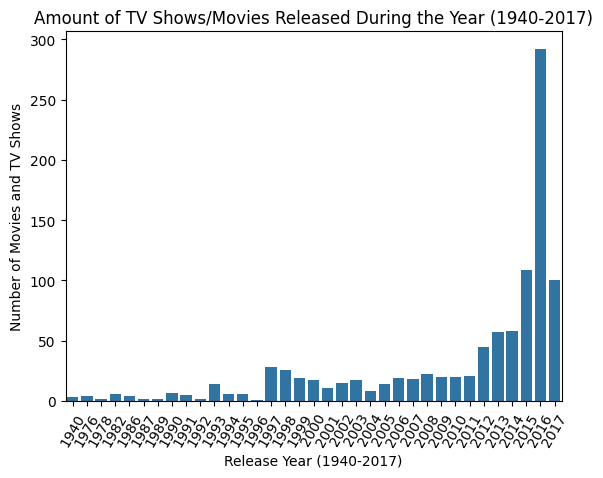

In [79]:
sns.barplot(year, x='release_year', y='count')

plt.title('Amount of TV Shows/Movies Released During the Year (1940-2017)')
plt.xlabel('Release Year (1940-2017)')
plt.ylabel('Number of Movies and TV Shows')
plt.xticks(rotation=60)

plt.show()

Most of the movies and TV shows in this Netflix dataset are from 1997 and beyond. The 2010s are especially popular, with 2016 being the most common release year in this dataset.

# Maturity Rating Dataset

The dataset contains information on the number of movies and TV shows on Netflix with a specific maturity rating.

## Data Preprocessing

In [80]:
by_rating = pd.read_csv('https://raw.githubusercontent.com/datacamp/community-groupby/refs/heads/master/data/chasewillden-netflix-shows/data/by_rating.csv')

In [81]:
by_rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   word    13 non-null     object 
 1   count   13 non-null     float64
dtypes: float64(1), object(1)
memory usage: 340.0+ bytes


In [82]:
by_rating.head()

,word,count
0,TV-MA,0.148
1,R,0.019
2,NR,0.014
3,UR,0.001
4,TV-14,0.234


In [83]:
by_rating.tail()

,word,count
8,TV-Y7,0.038
9,TV-Y7-FV,0.044
10,TV-Y,0.068
11,TV-G,0.052
12,G,0.138


In [84]:
# Get rid of any NaN and duplicate values
by_rating.dropna(inplace=True)
by_rating.drop_duplicates(inplace=True)

## Data Visualization

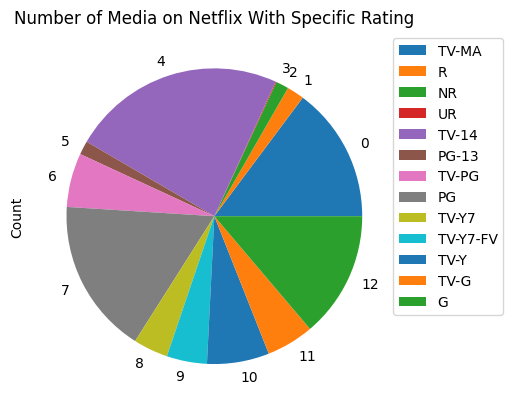

In [85]:
by_rating.plot.pie(x='word', y='count')

plt.title('Number of Media on Netflix With Specific Rating')
plt.ylabel('Count')
plt.legend(by_rating['word'], bbox_to_anchor=(1.3, 1), loc='upper right')

plt.show()

Most of the TV shows are rated TV-14 and TV-MA, whereas most of the movies are rated G and PG. There is a possibility that NR (Not Rated) and UR (Unrated) contains both movies and TV shows, as the two ratings are used for both media formats. NR and UR will, therefore, not be included in the analysis.


# Netflix Dataset

This dataset contains the names of the movies and TV shows, their release years, and different rating characteristics.

In [86]:
netflix = pd.read_csv('https://raw.githubusercontent.com/datacamp/community-groupby/refs/heads/master/data/chasewillden-netflix-shows/data/netflix.csv')

## Data Preprocessing

In [87]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1000 non-null   object 
 1   rating             1000 non-null   object 
 2   ratinglevel        941 non-null    object 
 3   ratingdescription  1000 non-null   int64  
 4   release_year       1000 non-null   int64  
 5   user_rating_score  605 non-null    float64
 6   user_rating_size   1000 non-null   int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB


In [88]:
netflix.head()

,title,rating,ratinglevel,ratingdescription,release_year,user_rating_score,user_rating_size
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",80,2004,82.0,80
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",100,2006,NaN,82
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,98.0,80
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2008,98.0,80
4,How I Met Your Mother,TV-PG,Parental guidance suggested. May not be suitab...,70,2014,94.0,80


In [89]:
netflix.tail()

,title,rating,ratinglevel,ratingdescription,release_year,user_rating_score,user_rating_size
995,The BFG,PG,"for action/peril, some scary moments and brief...",60,2016,97.0,80
996,The Secret Life of Pets,PG,for action and some rude humor,60,2016,NaN,81
997,Precious Puppies,TV-G,Suitable for all ages.,35,2003,NaN,82
998,Beary Tales,TV-G,Suitable for all ages.,35,2013,NaN,82
999,Growing Up Wild,G,NaN,35,2016,80.0,80


In [90]:
netflix.describe()

,ratingdescription,release_year,user_rating_score,user_rating_size
count,1000.00000,1000.000000,605.000000,1000.000000
mean,67.36600,2010.335000,84.094215,80.783000
std,30.78561,8.877927,12.344371,0.973066
min,10.00000,1940.000000,55.000000,80.000000
25%,35.00000,2007.000000,75.000000,80.000000
50%,60.00000,2015.000000,88.000000,80.000000
75%,90.00000,2016.000000,95.000000,82.000000
max,124.00000,2017.000000,99.000000,82.000000


Based on the information obtained, there are seven columns. The dataset did not come with information on what each of the columns represent, so this is assumed based on the data preprocessing conducted.

1. Title: Name of the movie or TV show
2. Rating: Maturity rating (TV-MA, PG-13, and so forth)
3. Rating Level: Description of the maturity rating
4. Rating Description: A rating score of sorts, most likely critics' rating scores
5. Release Year: Year movie or TV show was released (1940-2017)
6. User Rating Score: The rating score users gave the specific movie or TV show
7. User Rating Size: Number of people that rated the specific movie or TV show

As a result, the data analysis will be done assuming the Rating Description column represents the rating scores of critics.

In [91]:
netflix.dropna(inplace=True)
netflix.drop_duplicates(inplace=True)

# Drop NR and UR ratings
netflix.drop(netflix[netflix['rating'] == 'NR'].index, inplace=True)
netflix.drop(netflix[netflix['rating'] == 'UR'].index, inplace=True)

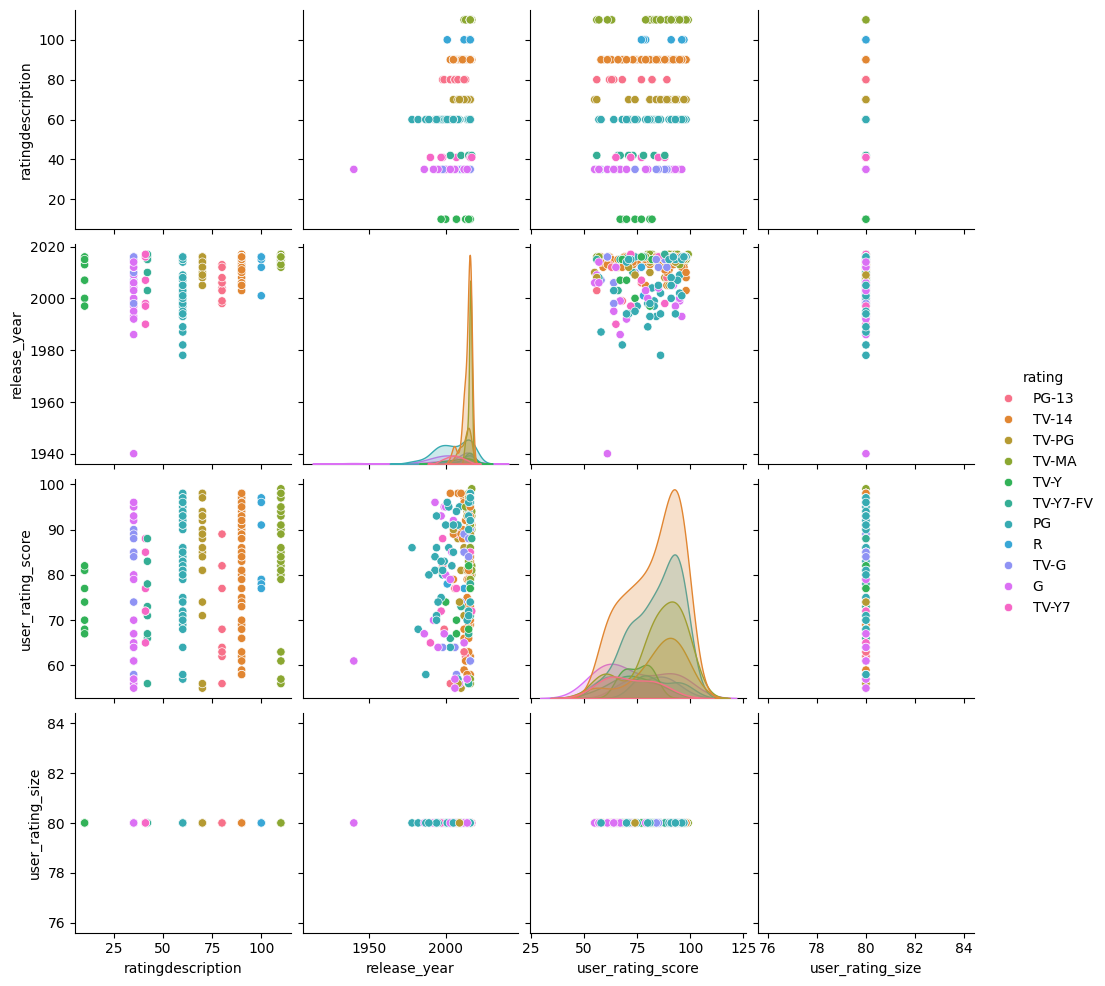

In [92]:
sns.pairplot(netflix, hue='rating')

The pairplot reveals certain areas of interest:

1.   User rating size is pretty consistent (around 80 participants) for all categories present in the dataset.
2.   User rating score and rating description can be investigated as functions of rating and time.
3. User rating score and rating description can be compared to see how users, on average, felt about the media compared to critics.

A size is given for user ratings, but not for rating description. It is possible that more or less critics rated the movies/TV shows compared to Netflix users. This data analysis will assume that the sizes of both groups are similar.

As a result, this data analysis will look at the relationship between critic and user rating scores.

## Data Visualizations and Analysis

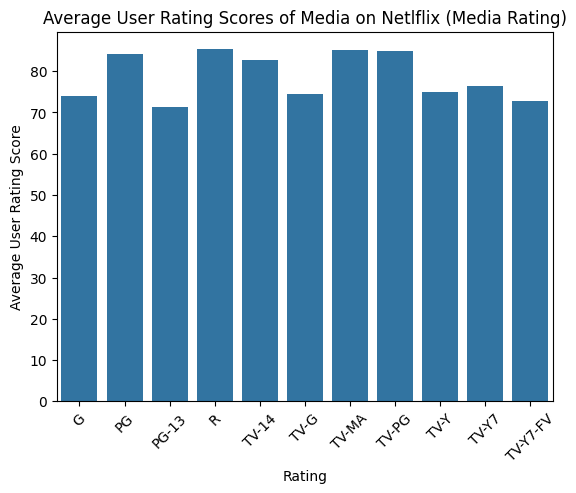

In [93]:
user_rating = netflix.groupby('rating')['user_rating_score'].mean()

sns.barplot(user_rating)

plt.title('Average User Rating Scores of Media on Netlflix (Media Rating)')
plt.xlabel('Rating')
plt.ylabel('Average User Rating Score')
plt.xticks(rotation=45)

plt.show()

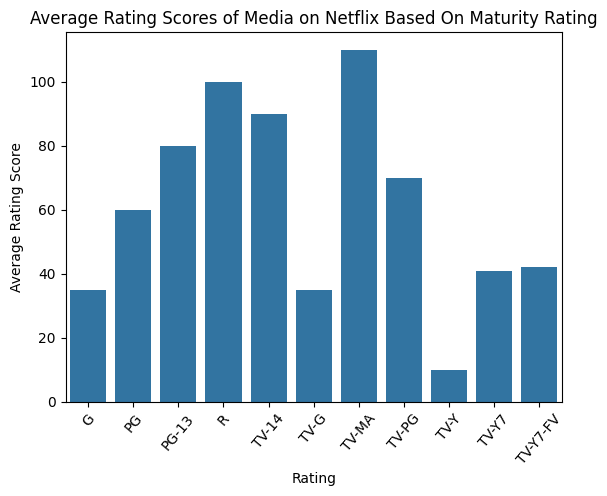

In [94]:
description_rating = netflix.groupby('rating')['ratingdescription'].mean()

sns.barplot(description_rating)

plt.title('Average Rating Scores of Media on Netflix Based On Maturity Rating')
plt.xlabel('Rating')
plt.ylabel('Average Rating Score')
plt.xticks(rotation=50)

plt.show()

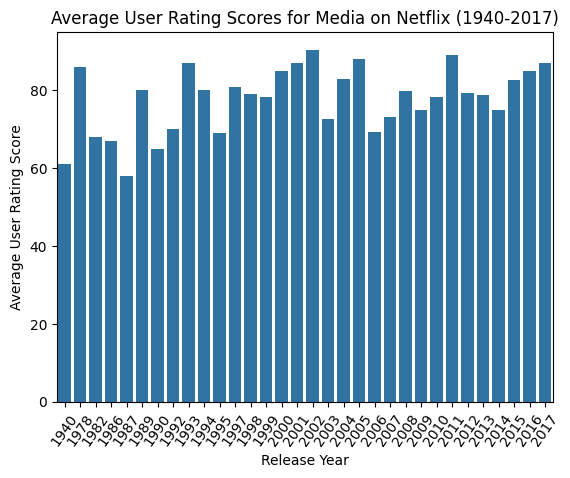

In [95]:
rating_score = netflix.groupby('release_year')['user_rating_score'].mean()

sns.barplot(rating_score)

plt.title("Average User Rating Scores for Media on Netflix (1940-2017)")
plt.xlabel("Release Year")
plt.ylabel("Average User Rating Score")
plt.xticks(rotation=55)

plt.show()

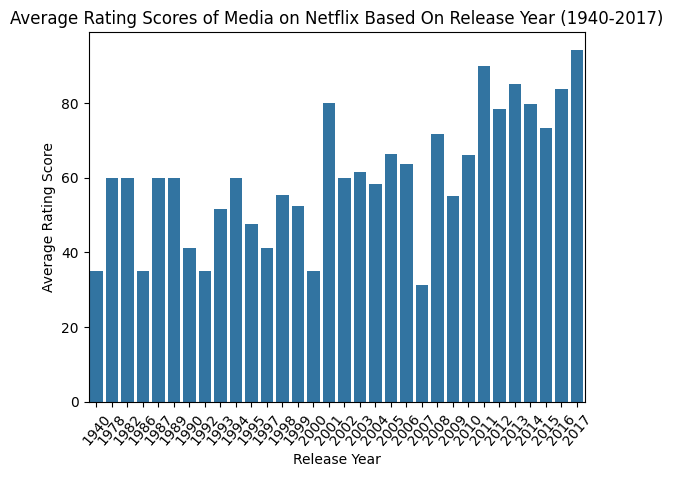

In [96]:
description_year = netflix.groupby('release_year')['ratingdescription'].mean()

sns.barplot(description_year)

plt.title('Average Rating Scores of Media on Netflix Based On Release Year (1940-2017)')
plt.xlabel('Release Year')
plt.ylabel('Average Rating Score')
plt.xticks(rotation=50)

plt.show()

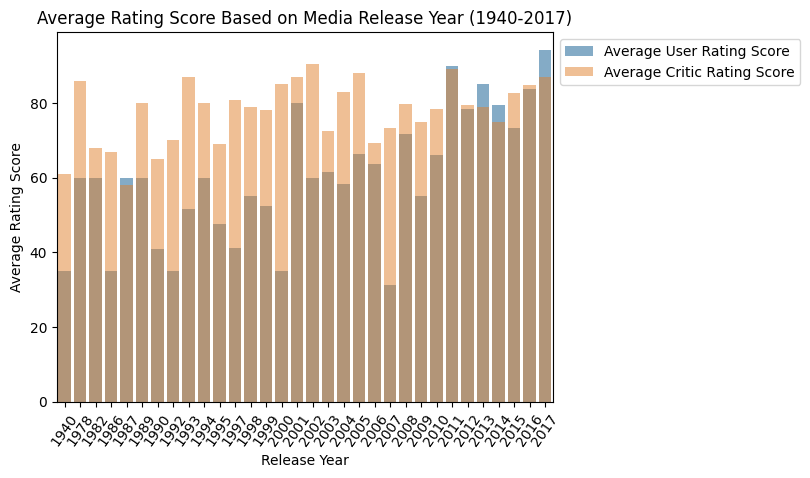

In [97]:
sns.barplot(description_year, alpha=0.6, label='Average User Rating Score')
sns.barplot(rating_score, alpha=0.5, label='Average Critic Rating Score')

plt.title('Average Rating Score Based on Media Release Year (1940-2017)')
plt.xlabel('Release Year')
plt.ylabel('Average Rating Score')
plt.xticks(rotation=55)
plt.legend(bbox_to_anchor=(1, 1))

plt.show()

Grouped by release year, critics seem to rate higher than users, but this could be due to a larger sample size for critics (which is unknown) than for Netflix users.

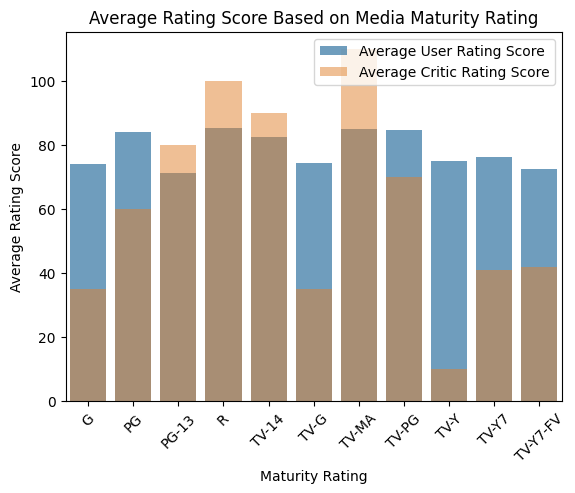

In [98]:
sns.barplot(user_rating, alpha=0.7, label='Average User Rating Score')
sns.barplot(description_rating, alpha=0.5, label='Average Critic Rating Score')

plt.title('Average Rating Score Based on Media Maturity Rating')
plt.xlabel('Maturity Rating')
plt.ylabel('Average Rating Score')
plt.xticks(rotation=45)
plt.legend()

plt.show()

The average rating scores for critics and users varies greatly depending on the maturity rating. Critics seem to have a higher average rating score for more mature ratings than for less mature ones.

Again, this could be due to sample size, but there could be other reasons. Critics can watch all ratings, but may be more likely to watch something more suited to their demographic, causing them to stay away from the more "childish" maturity ratings.

### Calculating Pearson Coefficient

In [99]:
print(f'Coefficient: {round(netflix['ratingdescription'].corr(netflix['user_rating_score']), 3)}')

Coefficient: 0.233


### Paired t-Test

The paired t-test will aim to answer the following: Do critics rate movies/TV shows differently than Netflix users?

Null Hypothesis
- Critic rating scores do NOT influence user rating scores. There is no significant difference between the two.

Alternate Hypothesis
- Critic rating scores influence user rating scores. The two are significantly significant.

In [100]:
stats.ttest_rel(netflix["ratingdescription"], netflix["user_rating_score"])

TtestResult(statistic=np.float64(-4.899761171857481), pvalue=np.float64(1.7535223962816234e-06), df=np.int64(243))

The p-value is less than 0.05, indicating it is statistically significant. The null hypothesis can be rejected.

## Is There a Relationship Between Critic and User Rating Scores?

The coefficient of 0.233 suggests a weak, positive linear relationship. User ratings don't increase when critic ratings do, and vice versa. It can suggest that critic ratings do not influence user ratings or cause them to change, though correlation does not always equate to causation, and it is possible that this relationship is best modeled nonlinearly.

The paired t-test p-value of 1.75e-06 indicates statistical significance and that critic rating scores **DO** influence user rating scores. It is possible that this could be better analyzed by a different statistical test, as the structure of the data may have skewed results or caused certain biases to appear.

Both seem plausible.

Netflix users can watch a movie/TV show without having heard anything about it. The standards to which critics hold media at also greatly differs to the standards the average watcher holds them at. There have been certain movies and TV shows that were hated on by critics, yet were loved by the public. As a result, critic rating scores not influencing user rating scores seems logical.

On the other hand, reputation greatly influences ratings. If critics deem a certain movie/TV show spectacular, that would no doubt grab people's interest and encourage them to see it. With this particular bit of information already in mind, people may be more likely to think positively of the movie/TV show and give them a higher rating.

As a result, there is most certainly a relationship between critic and user rating scores, but whether it is positive (yes, they influence each other) or negative (no, they do not influence each other) depends on many factors that are difficult to account for in analysis, and may not always be representable in mathematics.